In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns;sns.set()
from joblib import dump

In [4]:
from warnings import filterwarnings
filterwarnings("ignore")

# Get & Explore Data

In [5]:
# Load Data
data = pd.read_csv("house_prices_dataset.csv")
data.drop("Unnamed: 0",axis=1,inplace=True)
data

,property_type,price,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,Islamabad,2,For Sale,2,4.0
1,Flat,6900000,Islamabad,3,For Sale,3,5.6
2,House,16500000,Islamabad,6,For Sale,5,8.0
3,House,43500000,Islamabad,4,For Sale,4,40.0
4,House,7000000,Islamabad,3,For Sale,3,8.0
...,...,...,...,...,...,...,...
99494,Flat,7500000,Karachi,3,For Sale,3,8.0
99495,House,8800000,Karachi,4,For Sale,3,8.0
99496,House,14000000,Karachi,3,For Sale,3,8.0
99497,House,14000000,Karachi,4,For Sale,4,14.0


In [6]:
# Separate a Test Data
test_size = int(data.shape[0]*0.10)

data = data.sample(frac=1) # Shuffle the dataset

df = test_df = data.iloc[test_size:]
test_df = data.iloc[:test_size]

In [7]:
# Informations about the Data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89550 entries, 17682 to 92328
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  89550 non-null  object 
 1   price          89550 non-null  int64  
 2   city           89550 non-null  object 
 3   baths          89550 non-null  int64  
 4   purpose        89550 non-null  object 
 5   bedrooms       89550 non-null  int64  
 6   Area_in_Marla  89550 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 5.5+ MB


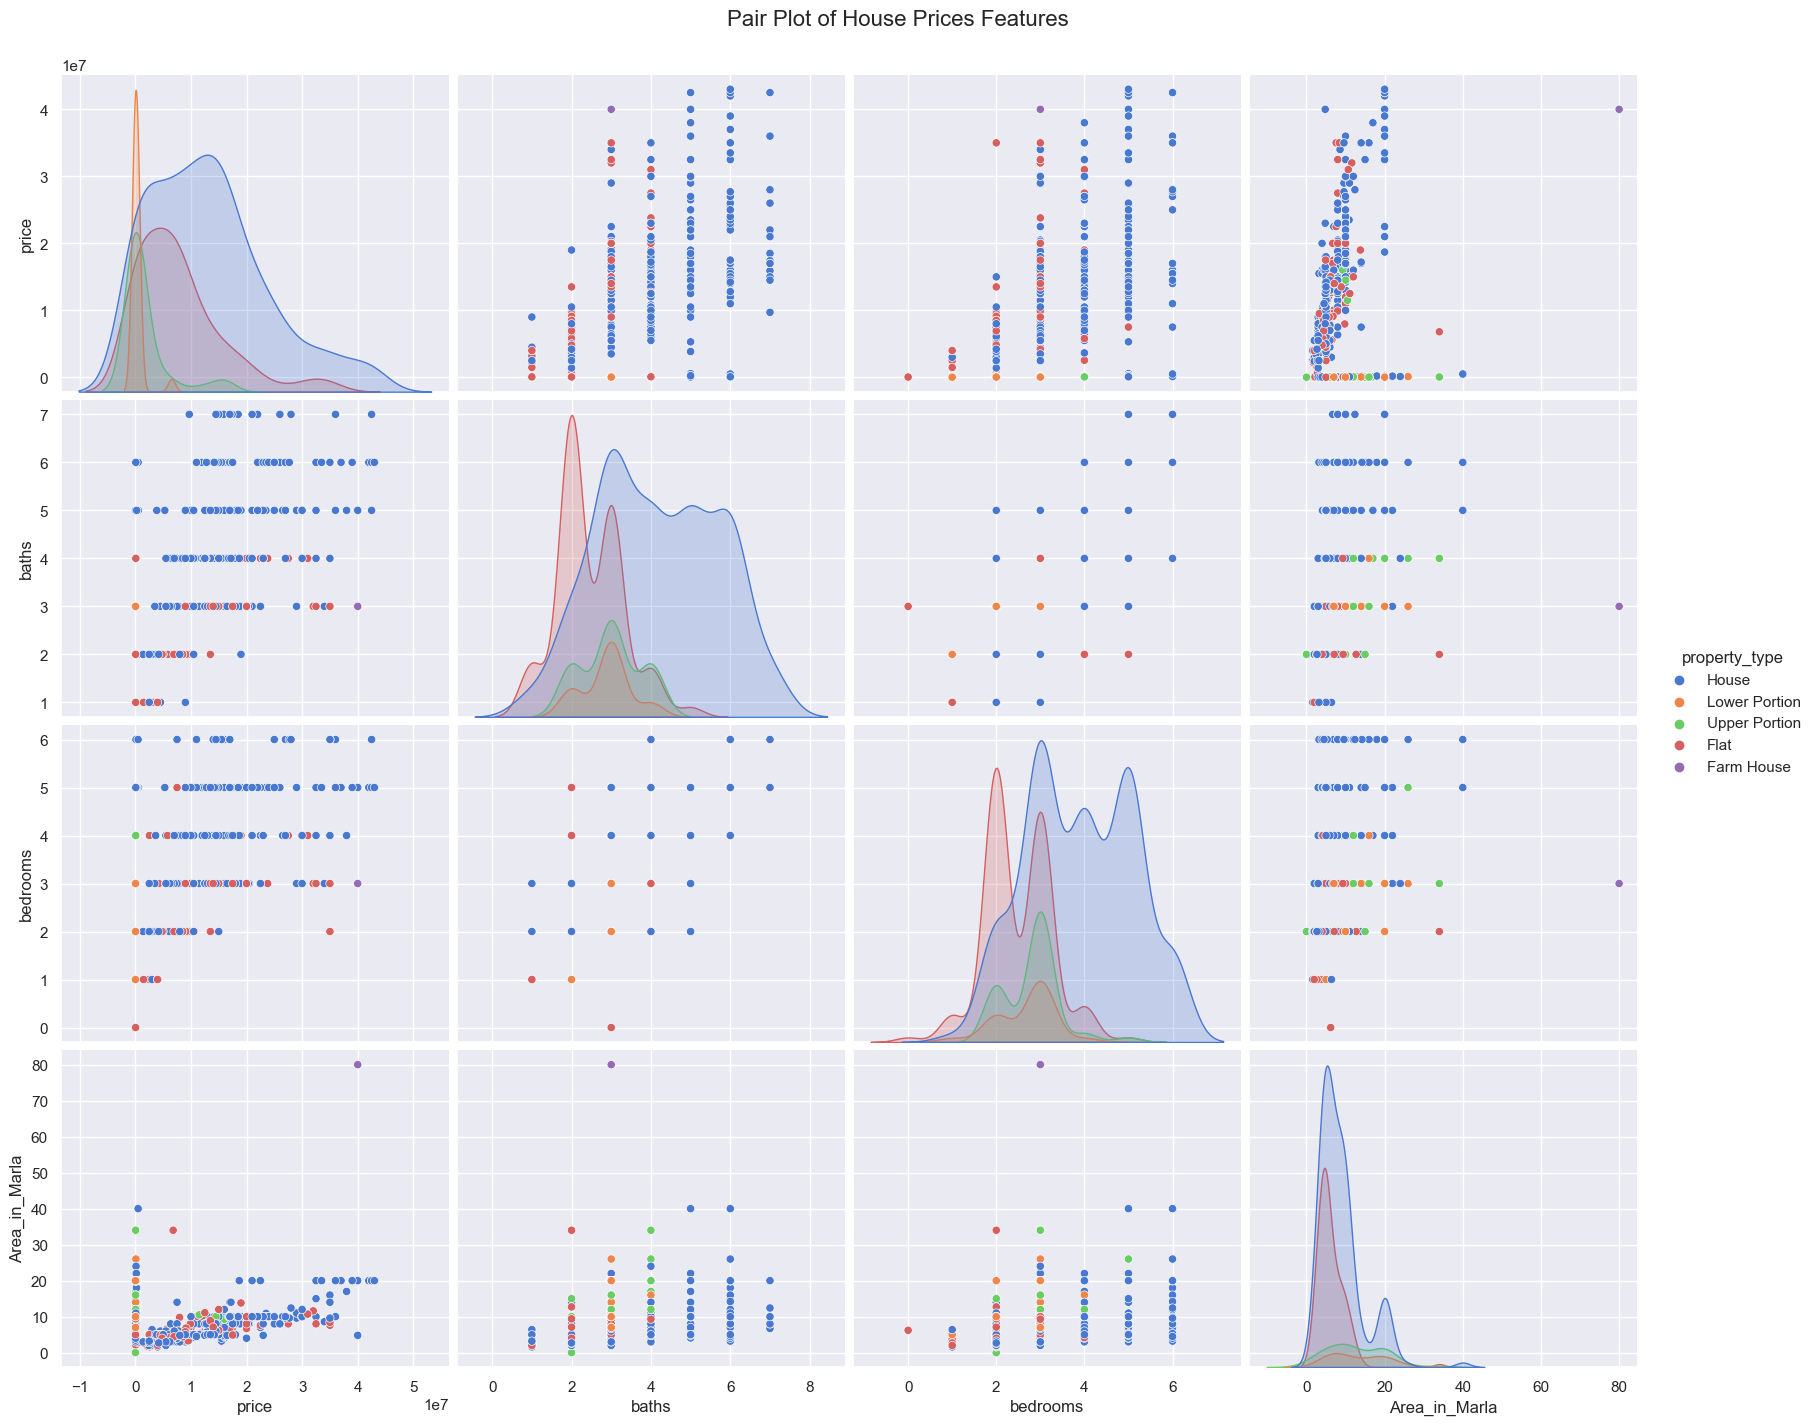

In [8]:
# Visualize the dataset
sns.pairplot(
    data=df.iloc[:500], 
    hue="property_type", 
    palette="muted", 
    kind="scatter", 
    height=3.5, 
    aspect=1.2, 
    diag_kind="kde"
)

# Show the plot
plt.suptitle("Pair Plot of House Prices Features", size=16, y=1.02)
plt.show()

# Prepare Data

## Cleaning

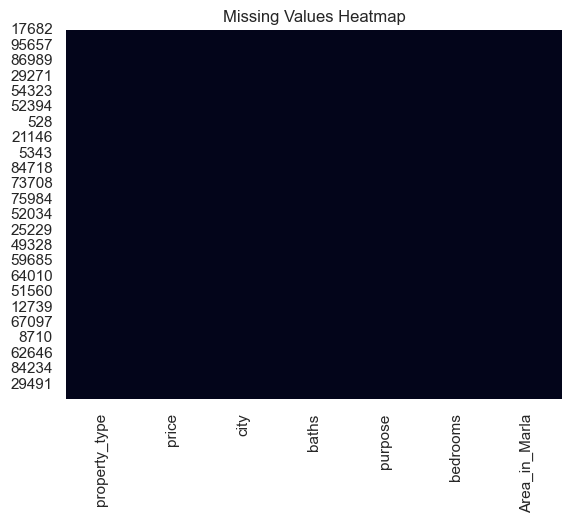

In [9]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

## Feature Engineering

In [10]:
df['bedroom_area'] = df['Area_in_Marla'] / df['bedrooms']
df['bath_area'] = df['Area_in_Marla'] / df['baths']

In [11]:
test_df['bedroom_area'] = test_df['Area_in_Marla'] / test_df['bedrooms']
test_df['bath_area'] = test_df['Area_in_Marla'] / test_df['baths']

## Text Encoding

In [12]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [13]:
df.property_type.unique()

array(['House', 'Lower Portion', 'Upper Portion', 'Flat', 'Farm House',
       'Penthouse', 'Room'], dtype=object)

In [14]:
ord_enc = OrdinalEncoder(categories=[['Farm House','Penthouse','Lower Portion','Upper Portion','Room','Flat','House']])
ord_enc.fit(df.property_type.values.reshape(-1,1))

OrdinalEncoder(categories=[['Farm House', 'Penthouse', 'Lower Portion',
                            'Upper Portion', 'Room', 'Flat', 'House']])

In [15]:
dump(ord_enc,"artifacts/property_type_encoder.pkl")

['artifacts/property_type_encoder.pkl']

In [16]:
df.property_type = ord_enc.transform(df.property_type.values.reshape(-1,1))
test_df.property_type = ord_enc.transform(test_df.property_type.values.reshape(-1,1))

In [17]:
label_enc = OrdinalEncoder()
label_enc.fit(df.city.values.reshape(-1,1))

OrdinalEncoder()

In [18]:
dump(label_enc,"artifacts/city_encoder.pkl")

['artifacts/city_encoder.pkl']

In [19]:
df.city = label_enc.transform(df.city.values.reshape(-1,1))
test_df.city = label_enc.transform(test_df.city.values.reshape(-1,1))

In [20]:
oh_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # dense output
oh_enc.fit(df[['purpose']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [21]:
dump(oh_enc,"artifacts/purpose_encoder.pkl")

['artifacts/purpose_encoder.pkl']

In [22]:
df.purpose.unique()

array(['For Sale', 'For Rent'], dtype=object)

In [23]:
def oh_transform(df, feature):
    array = df[[feature]]
    encoded_array = oh_enc.transform(array)

    column_names = oh_enc.get_feature_names_out([feature])
    
    encoded_df = pd.DataFrame(encoded_array, columns=column_names)

    df_encoded = df.join(encoded_df)
    df_encoded.drop(feature, axis=1, inplace=True)
    
    return df_encoded

In [24]:
new_df = oh_transform(df,"purpose")
new_df
#oh_transform(test_df,"purpose")

,property_type,price,city,baths,bedrooms,Area_in_Marla,bedroom_area,bath_area,purpose_For Rent,purpose_For Sale
17682,6.0,7000000,4.0,3,4,5.0,1.250000,1.666667,1.0,0.0
94567,6.0,7500000,3.0,4,4,3.0,0.750000,0.750000,NaN,NaN
92765,2.0,55000,1.0,2,2,8.0,4.000000,4.000000,NaN,NaN
44012,3.0,40000,1.0,4,3,20.0,6.666667,5.000000,0.0,1.0
90266,5.0,16000,1.0,1,1,3.8,3.800000,3.800000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
93295,5.0,28000,2.0,3,2,2.9,1.450000,0.966667,NaN,NaN
72591,6.0,21000000,2.0,3,3,8.0,2.666667,2.666667,1.0,0.0
97797,2.0,25000,1.0,2,2,4.0,2.000000,2.000000,NaN,NaN
12780,3.0,100000,2.0,4,4,40.0,10.000000,10.000000,1.0,0.0


In [25]:
test_df = test_df.reset_index().drop("index",axis=1).join(pd.DataFrame(oh_enc.transform(test_df[['purpose']]), columns=oh_enc.get_feature_names_out(['purpose'])))
test_df.drop("purpose",axis=1,inplace=True)

## Split Data

In [31]:
#new_df = new_df[~np.isinf(new_df.bedroom_area)]
#test_df = test_df[~np.isinf(test_df.bedroom_area)]

In [32]:
#new_df = new_df[~new_df['purpose_For Rent'].isnull()]

In [114]:
new_df.drop("price",axis=1)

,property_type,city,baths,bedrooms,Area_in_Marla,bedroom_area,bath_area,purpose_For Rent,purpose_For Sale
17682,6.0,4.0,3,4,5.0,1.250000,1.666667,1.0,0.0
44012,3.0,1.0,4,3,20.0,6.666667,5.000000,0.0,1.0
2177,3.0,1.0,4,4,17.0,4.250000,4.250000,1.0,0.0
26992,5.0,0.0,1,1,2.0,2.000000,2.000000,0.0,1.0
55353,5.0,2.0,3,3,5.8,1.933333,1.933333,1.0,0.0
...,...,...,...,...,...,...,...,...,...
2405,4.0,1.0,1,1,0.5,0.500000,0.500000,0.0,1.0
63327,6.0,3.0,5,5,10.0,2.000000,2.000000,1.0,0.0
11998,6.0,3.0,4,3,5.0,1.666667,1.250000,0.0,1.0
72591,6.0,2.0,3,3,8.0,2.666667,2.666667,1.0,0.0


In [33]:
# Split the dataset
X,y = new_df.drop("price",axis=1), new_df[['price']]

In [34]:
X_test,y_test = test_df.drop("price",axis=1), test_df[['price']]

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train,X_valid,y_train,y_valid = train_test_split(X,y,test_size=0.15)
X_train_small, y_train_small = X_train[:5000],y_train[:5000]

## Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

In [37]:
std_scaler = StandardScaler()
std_scaler.fit(X_train)

StandardScaler()

In [38]:
dump(std_scaler,"artifacts/scaler.pkl")

['artifacts/scaler.pkl']

In [40]:
X_train = std_scaler.transform(X_train)
X_valid = std_scaler.transform(X_valid)
X_test = std_scaler.transform(X_test)

# Shortlist Promising Models

## Linear Regression

In [41]:
from sklearn.linear_model import Ridge

In [42]:
lr = Ridge()
lr.fit(X_train,y_train)

Ridge()

In [43]:
lr.score(X_train,y_train)

0.30694602742468224

In [45]:
lr.score(X_valid,y_valid)

0.29683641709106223

## Polynomial Regression

In [46]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [47]:
poly_reg = make_pipeline(PolynomialFeatures(degree=2),
                        Ridge())
poly_reg.fit(X_train,y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('ridge', Ridge())])

In [48]:
poly_reg.score(X_train,y_train)

0.41649203107716226

In [49]:
poly_reg.score(X_valid,y_valid)

0.40027406835810786

# Support Vector Machine

In [50]:
from sklearn.svm import SVR

In [51]:
linr_svr = SVR()
linr_svr.fit(X_train_small,y_train_small)

SVR()

In [52]:
linr_svr.score(X_train_small,y_train_small)

-0.05930842742337816

In [53]:
linr_svr.score(X_valid,y_valid)

-0.05432241101904123

In [54]:
poly_svr = SVR(kernel='poly',degree=2)
poly_svr.fit(X_train_small,y_train_small)

SVR(degree=2, kernel='poly')

In [55]:
poly_svr.score(X_train_small,y_train_small)

-0.05933871073104924

In [56]:
poly_svr.score(X_valid,y_valid)

-0.05431713090055279

In [57]:
rbf_svr = SVR(kernel='rbf')
rbf_svr.fit(X_train_small,y_train_small)

SVR()

In [58]:
rbf_svr.score(X_train_small,y_train_small)

-0.05930842742337816

In [59]:
rbf_svr.score(X_valid,y_valid)

-0.05432241101904123

## K-Nearest Neighbors

In [60]:
from sklearn.neighbors import KNeighborsRegressor

In [61]:
knn = KNeighborsRegressor()
knn.fit(X_train_small,y_train_small)

KNeighborsRegressor()

In [62]:
knn.score(X_train,y_train)

-0.7629165608032706

In [63]:
knn.score(X_valid,y_valid)

-0.7569671176641444

## Decision Tree

In [64]:
from sklearn.tree import DecisionTreeRegressor

In [65]:
tree_reg = DecisionTreeRegressor()
tree_reg.fit(X_train,y_train)

DecisionTreeRegressor()

In [66]:
tree_reg.score(X_train,y_train)

0.6822841176498349

In [67]:
tree_reg.score(X_valid,y_valid)

0.5375111522823498

## Random Forest

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train,y_train)

RandomForestRegressor()

In [70]:
forest_reg.score(X_train,y_train)

0.6757318119780665

In [71]:
forest_reg.score(X_valid,y_valid)

0.5746832310662386

<Axes: >

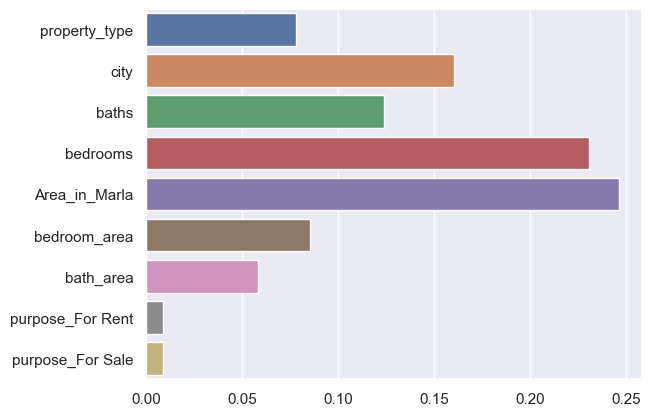

In [76]:
# Visualize Features Importances
sns.barplot(x=forest_reg.feature_importances_,y=new_df.drop("price",axis=1).columns)

# Fine-Tunning

In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
param_grid = {
    'max_depth': [2, 3, 4, 5],              
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [5, 10, 20]
}

# Grid search
grid_search = GridSearchCV(estimator=tree_reg,
                           param_grid=param_grid,
                           cv=5,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [5, 10, 20],
                         'min_samples_split': [5, 10, 20]},
             scoring='neg_mean_squared_error', verbose=1)

In [79]:
tree_reg_tuned = grid_search.best_estimator_

In [80]:
tree_reg_tuned.score(X_train, y_train)

0.522531046359572

In [81]:
tree_reg_tuned.score(X_valid, y_valid)

0.5020160356300785

In [82]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [4, 6, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=forest_reg,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [4, 6, 10],
                         'min_samples_split': [5, 10],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_squared_error', verbose=1)

In [83]:
forest_reg_tuned = grid_search.best_estimator_

In [84]:
forest_reg_tuned.score(X_train, y_train)

0.6080456463974877

In [85]:
forest_reg_tuned.score(X_valid, y_valid)

0.579394617378086

In [86]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=1)

In [87]:
knn_tuned = grid_search.best_estimator_

In [88]:
knn_tuned.score(X_train,y_train)

0.6003017644177934

In [89]:
knn_tuned.score(X_valid, y_valid)

0.5434052809556784

In [90]:
param_grid = {
    'polynomialfeatures__degree': [2, 3],
    'ridge__alpha': [0.01, 0.1, 1.0, 10.0],
    'ridge__solver': ['auto', 'svd', 'cholesky']
}

grid_search = GridSearchCV(
    estimator=poly_reg,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [2, 3],
                         'ridge__alpha': [0.01, 0.1, 1.0, 10.0],
                         'ridge__solver': ['auto', 'svd', 'cholesky']},
             scoring='neg_mean_squared_error', verbose=1)

In [91]:
poly_reg_tuned = grid_search.best_estimator_

In [92]:
poly_reg_tuned.score(X_train, y_train)

0.41649147642088125

In [93]:
poly_reg_tuned.score(X_valid, y_valid)

0.4002866724576519

In [94]:
from xgboost import XGBRegressor

In [95]:
xgb = XGBRegressor(n_estimators=50, max_depth=10)
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [96]:
xgb.score(X_train,y_train)

0.6688608600188974

In [97]:
xgb.score(X_valid,y_valid)

0.583676220631725

In [98]:
from lightgbm import LGBMRegressor

In [99]:
lgbm = LGBMRegressor(max_bin=256, n_estimators=100)
lgbm.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 732
[LightGBM] [Info] Number of data points in the train set: 68281, number of used features: 9
[LightGBM] [Info] Start training from score 10489460.335525


LGBMRegressor(max_bin=256)

In [100]:
lgbm.score(X_train,y_train)

0.6151253417568207

In [101]:
lgbm.score(X_valid,y_valid)

0.5901183202359701

# Ensemble Methods

In [102]:
from sklearn.ensemble import VotingRegressor

In [103]:
voting_reg = VotingRegressor(estimators=[("decision_tree",tree_reg_tuned),
                                         ("random_forest",forest_reg_tuned),
                                         ("knn",knn_tuned),
                                         ("xgboost",xgb),
                                         ])#("lgmboost",lgbm)#,("polynomial_regression",poly_reg_tuned)])
voting_reg.fit(X_train,y_train)

VotingRegressor(estimators=[('decision_tree',
                             DecisionTreeRegressor(max_depth=5,
                                                   min_samples_leaf=5,
                                                   min_samples_split=10)),
                            ('random_forest',
                             RandomForestRegressor(max_depth=10,
                                                   max_features='sqrt',
                                                   min_samples_leaf=4,
                                                   min_samples_split=5)),
                            ('knn', KNeighborsRegressor(n_neighbors=9)),
                            ('xgboost',
                             XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsa...
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=10,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=50,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=None, ...))])

In [104]:
voting_reg.score(X_train, y_train)

0.6288178441354613

In [105]:
voting_reg.score(X_valid, y_valid)

0.5817395497658826

In [106]:
from sklearn.ensemble import StackingRegressor

In [107]:
base_learners = [
("decision_tree",tree_reg_tuned),
("random_forest",forest_reg_tuned),
("knn",knn_tuned),
("xgboost",xgb)
]
meta_learner = lgbm
stack_reg = StackingRegressor(estimators=base_learners,
final_estimator=meta_learner)
stack_reg.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 915
[LightGBM] [Info] Number of data points in the train set: 68281, number of used features: 4
[LightGBM] [Info] Start training from score 10489460.335525


StackingRegressor(estimators=[('decision_tree',
                               DecisionTreeRegressor(max_depth=5,
                                                     min_samples_leaf=5,
                                                     min_samples_split=10)),
                              ('random_forest',
                               RandomForestRegressor(max_depth=10,
                                                     max_features='sqrt',
                                                     min_samples_leaf=4,
                                                     min_samples_split=5)),
                              ('knn', KNeighborsRegressor(n_neighbors=9)),
                              ('xgboost',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            col...
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=10,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=50, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...))],
                  final_estimator=LGBMRegressor(max_bin=256))

In [108]:
stack_reg.score(X_train, y_train)

0.6371444916367925

In [109]:
stack_reg.score(X_valid, y_valid)

0.5891631451831041

In [110]:
dump(stack_reg,filename="artifacts/estimator.pkl")

['artifacts/estimator.pkl']

# Evaluation

In [111]:
from sklearn.model_selection import cross_val_score

In [112]:
cross_val_score(stack_reg, X_test, y_test, cv=3, scoring='r2')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 909
[LightGBM] [Info] Number of data points in the train set: 6616, number of used features: 4
[LightGBM] [Info] Start training from score 10502162.161427
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 6617, number of used features: 4
[LightGBM] [Info] Start training from score 10448034.619918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the tr

array([0.81912399, 0.80771726, 0.80692898])

<h2>Amazing</h2>
We reached 0.82 R2.